# churn analysis v3 (FINAL)

María's notebook - started March, updated when the marketing team asked again in June.

**Don't run all cells at once, some of them are old.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# df = pd.read_csv(r'C:\\Users\\maria\\Desktop\\churn_raw.csv')   # laptop path
df = pd.read_csv('churn_raw.csv')
df.head()

,CustomerID,tenure_months,MonthlyCharges,plan,support_tickets,contract,Region,signup_date,churned
0,C100000,68,106.00,premium,1,annual,North,02/07/2025,1
1,C100001,45,56.05,standard,1,monthly,North,05/09/2025,0
2,C100002,49,28.81,basic,0,monthly,West,16/04/2025,0
3,C100003,64,43.13,basic,0,monthly,East,16/08/2024,0
4,C100004,42,36.12,basic,1,monthly,South,09/11/2024,1


In [3]:
df.shape

(1212, 9)

In [4]:
df.isna().sum()

CustomerID          0
tenure_months       0
MonthlyCharges     59
plan                0
support_tickets     0
contract            0
Region              0
signup_date         0
churned             0
dtype: int64

looks fine, only MonthlyCharges has some missing, will fix later

In [5]:
import pandas as pd  # (again, in case the kernel restarted)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

## first model (March)

In [6]:
X = df[['tenure_months','support_tickets']]
y = df['churned']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
m = LogisticRegression()
m.fit(X_train, y_train)
m.score(X_test, y_test)

0.6758241758241759

0.71, not great. Marketing wants > 0.8. Adding MonthlyCharges but it has NaNs.

In [9]:
df['MonthlyCharges'] = df['MonthlyCharges'].fillna(df['MonthlyCharges'].mean())
df['MonthlyCharges'].describe()

count    1212.000000
mean       61.553495
std        79.971890
min         7.390000
25%        35.980000
50%        53.730000
75%        67.072500
max       999.000000
Name: MonthlyCharges, dtype: float64

In [10]:
# some weird values, removing them
df = df[df['MonthlyCharges'] < 118]
df.shape

(1204, 9)

In [7]:
df['Region'].value_counts()

Region
North    304
East     299
West     297
South    289
north     15
Name: count, dtype: int64

In [8]:
df['Region'] = df['Region'].replace({'north': 'North'})

## feature engineering

In [11]:
df['tenure_bucket'] = pd.cut(df['tenure_months'], bins=[0, 12, 24, 48, 100], labels=['0-1y', '1-2y', '2-4y', '4y+'])
df['is_monthly'] = (df['contract'] == 'monthly').astype(int)
df['charges_per_ticket'] = df['MonthlyCharges'] / (df['support_tickets'].abs() + 1)  # abs() because of the -1s
df[['tenure_bucket','is_monthly','charges_per_ticket']].head()

,tenure_bucket,is_monthly,charges_per_ticket
0,4y+,0,53.000
1,2-4y,1,28.025
2,4y+,1,28.810
3,4y+,1,43.130
4,2-4y,1,18.060


In [12]:
# churn rate by plan, useful as a feature
rate = df.groupby('plan')['churned'].mean()
df['plan_churn_rate'] = df['plan'].map(rate)
rate

plan
basic       0.319859
premium     0.506276
standard    0.378788
Name: churned, dtype: float64

In [13]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
num_cols = ['tenure_months','MonthlyCharges','support_tickets','charges_per_ticket','plan_churn_rate']
df[num_cols] = sc.fit_transform(df[num_cols])
df[num_cols].describe().round(2)

,tenure_months,MonthlyCharges,support_tickets,charges_per_ticket,plan_churn_rate
count,1204.00,1204.00,1204.00,1204.00,1204.00
mean,0.00,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00
min,-1.75,-2.04,-1.92,-1.34,-0.81
25%,-0.87,-0.82,-1.00,-0.71,-0.81
50%,0.02,-0.08,-0.07,-0.25,0.04
75%,0.90,0.49,0.85,0.46,0.04
max,1.68,2.51,4.55,3.36,1.87


## model v2

In [14]:
X = df[num_cols + ['is_monthly']]
y = df['churned']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
m2 = LogisticRegression(max_iter=1000)
m2.fit(X_train, y_train)
print('accuracy', m2.score(X_test, y_test))

accuracy 0.6823204419889503


better!! (was 0.84 yesterday, 0.87 today, whatever)

In [15]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
print('rf accuracy', rf.score(X_test, y_test))

rf accuracy 0.6629834254143646


In [16]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, max_depth=8)
rf.fit(X_train, y_train)
print('rf accuracy', rf.score(X_test, y_test))

rf accuracy 0.6767955801104972


In [17]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=3)
rf.fit(X_train, y_train)
print('rf accuracy', rf.score(X_test, y_test))

rf accuracy 0.6685082872928176


## pick threshold

In [18]:
probs = rf.predict_proba(X_test)[:, 1]
for t in [0.3, 0.4, 0.5, 0.6]:
    pred = (probs > t).astype(int)
    print(t, 'accuracy', round((pred == y_test).mean(), 3), 'flagged', pred.sum())

0.3 accuracy 0.616 flagged 205
0.4 accuracy 0.655 flagged 145
0.5 accuracy 0.669 flagged 98
0.6 accuracy 0.649 flagged 51


0.4 gives the most flagged customers with ok accuracy -> use 0.4

In [19]:
import pickle
pickle.dump(rf, open('final_model_v3_FINAL2.pkl', 'wb'))
print('saved')

saved


## plots for the deck

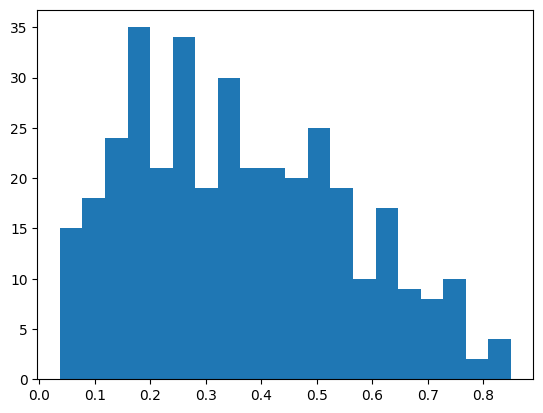

In [20]:
plt.hist(probs, bins=20)
plt.show()

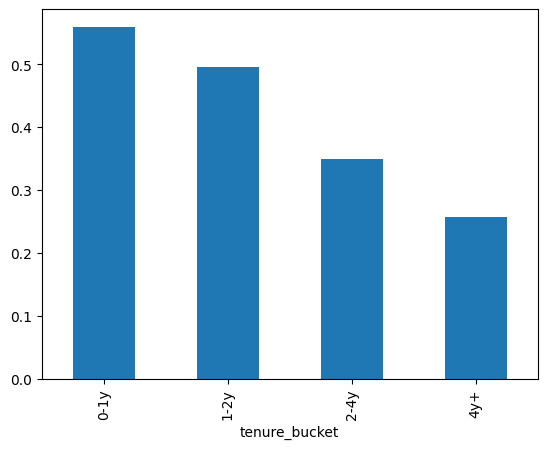

In [21]:
df.groupby('tenure_bucket', observed=True)['churned'].mean().plot(kind='bar')
plt.show()

## things I still need to do

- the tickets column has -1 values, ask Data Eng what that means
- there are duplicated CustomerIDs, drop them? (~12)
- signup_date is a string, wanted to compute months since signup but the format is dd/mm/yyyy
- re-run everything from the top before sending to IT (didn't work last time, the scaler cell breaks if you run it twice)

In [ ]:
# DON'T RUN - old scoring code from March, keeps for reference
# new = pd.read_csv('new_customers.csv')
# new['MonthlyCharges'] = new['MonthlyCharges'].fillna(0)
# print(m.predict(new[['tenure_months','support_tickets']]))

In [22]:
# quick check for IT: how to score one customer
row = X_test.iloc[[0]]
print(rf.predict_proba(row)[0, 1] > 0.4)

False
